# Stellar Sample Characterization

This notebook characterizes the pool of nearby bright TESS stars we plan to use for the stellar world model.
It covers sample selection, physical parameter distributions, TESS data availability, and a demonstration that Gaia BP-RP color breaks the log g / Teff degeneracy.

**Put together a notebook to explore two suggestions — the bright nearby stars filter and the degeneracy issue**

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from astroquery.mast import Catalogs
import lightkurve as lk

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

---
## Section 1: Query Bright Nearby Stars from TIC v8 (TESS Input Catalog)

Criteria: TESS magnitude < 10, parallax > 10 mas (distance < 100 pc), object type = STAR.

In [3]:
import time

# MAST sometimes drops the connection on large payloads — bump the client timeout
Catalogs.TIMEOUT = 300

def query_tic_with_retry(criteria, max_retries=4, base_wait=8):
    """Query MAST TIC with retry on connection errors (RemoteDisconnected, etc)."""
    last_err = None
    for attempt in range(1, max_retries + 1):
        try:
            print(f"  MAST attempt {attempt}/{max_retries} with {criteria}...")
            return Catalogs.query_criteria(catalog="TIC", **criteria)
        except Exception as e:
            last_err = e
            print(f"    {type(e).__name__}: {str(e)[:150]}")
            if attempt < max_retries:
                wait = base_wait * attempt
                print(f"    Retrying in {wait}s...")
                time.sleep(wait)
    raise last_err

print("Querying TIC v8 from MAST...")
try:
    catalog = query_tic_with_retry(dict(
        Tmag=[-99, 10],
        plx=[10, 9999],
        objType="STAR",
    ))
except Exception as e:
    print(f"\nQuery failed after retries ({type(e).__name__}).")
    print("Falling back to a tighter filter (plx > 20 mas, d < 50 pc) to shrink the payload...")
    catalog = query_tic_with_retry(dict(
        Tmag=[-99, 10],
        plx=[20, 9999],
        objType="STAR",
    ))

print(f"\nMAST returned {len(catalog)} rows.\n")

# Convert full table first — column names vary by astroquery version (e.g. gaiaBP vs gaiaBp)
df_all = catalog.to_pandas()
for col in df_all.columns:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

# Case-insensitive column lookup
col_lower = {c.lower(): c for c in df_all.columns}

def get_col(*candidates):
    for name in candidates:
        found = col_lower.get(name.lower())
        if found:
            return found
    return None

bp_col = get_col('gaiaBP', 'gaiaBp', 'gaia_bp')
rp_col = get_col('gaiaRP', 'gaiaRp', 'gaia_rp')
g_col  = get_col('GAIAmag', 'gaiamag', 'gaia_g')
print(f"Gaia columns found → G: {g_col},  BP: {bp_col},  RP: {rp_col}")

required_cols = ['ID', 'Tmag', 'Teff', 'logg', 'MH', 'plx', 'rad', 'mass']
extra_cols = [c for c in [g_col, bp_col, rp_col] if c is not None]
df_raw = df_all[required_cols + extra_cols].copy()

# Standardize names so downstream cells always see 'gaiaBp', 'gaiaRp', 'GAIAmag'
rename = {}
if bp_col and bp_col != 'gaiaBp':  rename[bp_col] = 'gaiaBp'
if rp_col and rp_col != 'gaiaRp':  rename[rp_col] = 'gaiaRp'
if g_col  and g_col  != 'GAIAmag': rename[g_col]  = 'GAIAmag'
if rename:
    df_raw = df_raw.rename(columns=rename)

print(f"Total stars returned: {len(df_raw)}")
df_raw.head(10)

Querying TIC v8 from MAST...
  MAST attempt 1/4 with {'Tmag': [-99, 10], 'plx': [10, 9999], 'objType': 'STAR'}...

MAST returned 41233 rows.

Gaia columns found → G: GAIAmag,  BP: gaiabp,  RP: gaiarp
Total stars returned: 41233


,ID,Tmag,Teff,logg,MH,plx,rad,mass,GAIAmag,gaiaBp,gaiaRp
0,83955820,9.8090,3994.00,4.59206,NaN,26.2117,0.659480,0.62,10.65030,11.53050,9.75518
1,83959472,9.6831,5223.00,4.56881,NaN,12.1159,0.811567,0.89,10.20750,10.64640,9.63191
2,117927293,5.9418,6384.00,3.81453,NaN,16.5095,2.319380,1.28,6.30145,6.58443,5.90321
3,117929446,8.8397,5148.00,4.58053,NaN,18.8693,0.791644,0.87,9.37813,9.83911,8.79446
4,257487686,8.7630,5676.00,4.47786,NaN,13.3949,0.959988,1.01,9.20916,9.57019,8.71816
5,378534800,6.7085,5660.00,3.82940,NaN,16.4402,2.025310,1.01,7.15730,7.52977,6.67240
6,117926681,8.3179,6017.00,4.31067,NaN,11.6855,1.220000,1.11,8.71114,9.02110,8.27469
7,117930174,9.7533,5182.27,4.62024,-0.181000,12.7535,0.760599,0.88,10.27940,10.72350,9.70542
8,117956546,5.0430,5365.25,NaN,-0.844312,79.0696,0.866258,NaN,5.52379,5.93117,5.00820
9,201439491,8.5870,5292.00,4.51655,NaN,18.2357,0.871523,0.91,9.09865,9.52609,8.53870


## Quality Cuts

Filtering the TIC sample to stars suitable for Conv1D-VAE training.  
Cuts are applied in sequence; survival count is printed after each step.

In [ ]:
import pandas as pd
import numpy as np

# Apply quality cuts in sequence starting from the full TIC query result (df_raw)
current = df_raw.copy()
print(f"Initial TIC sample: {len(current)} stars")

# Cut 1: Tmag < 7  (signal-to-noise — fainter stars show visibly noisy TESS light curves)
prev = len(current)
current = current[current['Tmag'] < 7]
_n_after_tmag = len(current)
print(f"After Tmag < 7: {_n_after_tmag} stars remaining (dropped {prev - _n_after_tmag})")

# Cut 2: parallax > 10 mas  (distance < 100 pc — lower extinction, better Gaia parameter quality)
prev = len(current)
current = current[current['plx'] > 10]
_n_after_plx = len(current)
print(f"After parallax > 10 mas: {_n_after_plx} stars remaining (dropped {prev - _n_after_plx})")

# Cut 3: exclude SPLIT sources  (unresolved 2MASS doubles — unreliable photometry/parameters)
if 'disposition' in current.columns:
    prev = len(current)
    current = current[current['disposition'] != 'SPLIT']
    _n_after_split = len(current)
    print(f"After excluding SPLIT: {_n_after_split} stars remaining (dropped {prev - _n_after_split})")
else:
    _n_after_split = None
    print("Warning: 'disposition' column not found in TIC query result — skipping SPLIT exclusion step.")

df_clean = current.reset_index(drop=True)
print(f"\ndf_clean: {len(df_clean)} stars ready for TESS availability check.")
print(f"  (Teff/logg nulls kept — labels will be cross-matched from multiple sources later)")

Initial TIC sample: 41233 stars
After Tmag < 7: 7121 stars remaining (dropped 34112)
After parallax > 10 mas: 7121 stars remaining (dropped 0)

df_clean: 7121 stars ready for TESS availability check.
  (Teff/logg nulls kept — labels will be cross-matched from multiple sources later)


### TESS 2-min Cadence Availability Check

For each star in `df_clean`, check whether TESS 2-min cadence (SPOC) data exists,
and how many sectors are available.

In [5]:
import lightkurve as lk
import pandas as pd
import numpy as np
import os
import sys
import time
import threading
import requests
from astroquery.mast import Observations

CHECKPOINT_PATH       = "sector_check_results.csv"
PROGRESS_EVERY        = 10     # print every N stars
CHECKPOINT_EVERY      = 25     # flush CSV every N stars
QUERY_TIMEOUT         = 20     # astroquery's real socket-level cap
THREAD_TIMEOUT        = 25     # belt-and-suspenders cap (fires only if astroquery's own timeout misses)
QUERY_DELAY           = 0.5    # politeness sleep between queries
ABORT_AFTER_BAD       = 30     # abort if this many consecutive queries fail/timeout
WARMUP_TIC            = 117956546   # known-good ID from df_clean for sanity check

# Critical: set astroquery's real socket-level timeout. lk.search_lightcurve
# uses Observations under the hood. Without this, the threading wrapper below
# could return 'timeout' while the underlying HTTP request kept running and
# held a slot in astroquery's shared connection pool. A few stuck requests
# filled the pool, and then every subsequent query blocked the full 20s
# waiting for a free slot even though MAST itself was fine — that's the
# cluster of back-to-back 20.0s timeouts seen in the previous run.
Observations.TIMEOUT = QUERY_TIMEOUT

def _reset_mast_session():
    """Drop astroquery's HTTP session so any dangling/zombie connection in the
    pool is closed. Called after each timeout to break the feedback loop."""
    try:
        sess = getattr(Observations, '_session', None)
        if sess is not None:
            sess.close()
    except Exception:
        pass
    try:
        Observations._session = requests.Session()
    except Exception:
        pass

print(f"df_clean has {len(df_clean)} rows", flush=True)

# ── Resume from checkpoint ──────────────────────────────────────────────────
if os.path.exists(CHECKPOINT_PATH):
    existing = pd.read_csv(CHECKPOINT_PATH)
    records  = existing.to_dict('records')
    done_ids = set(existing['TIC_ID'].astype(int))
    print(f"Resuming: {len(records)} stars already in {CHECKPOINT_PATH}, skipping them.", flush=True)
else:
    records  = []
    done_ids = set()

todo = df_clean[~df_clean['ID'].astype(int).isin(done_ids)].copy()
print(f"Stars remaining: {len(todo)}  (already done: {len(done_ids)})  total: {len(df_clean)}", flush=True)

if len(todo) == 0:
    print("All stars already checked. Loading from checkpoint.", flush=True)
    df_sectors = pd.read_csv(CHECKPOINT_PATH)
else:
    # ── Per-query timeout (daemon thread, Windows-compatible) ───────────────
    # The thread is a backup: astroquery's Observations.TIMEOUT should normally
    # raise first at QUERY_TIMEOUT, surfacing here as status='error:Timeout'
    # (or similar). The thread cap (THREAD_TIMEOUT) only fires if astroquery's
    # own timeout misses (e.g. a stuck DNS lookup before the socket layer).
    def search_with_timeout(tic_id, timeout=THREAD_TIMEOUT):
        """Returns (n_sectors, sector_list, status) where status ∈ {ok, timeout, error:<msg>}."""
        result = [0, []]
        exc    = [None]
        def _run():
            try:
                sr = lk.search_lightcurve(f"TIC {tic_id}", mission="TESS", author="SPOC", exptime=120)
                n  = len(sr)
                try:
                    sectors = list(sr.table['sequence_number']) if n > 0 else []
                except Exception:
                    sectors = []
                result[0], result[1] = n, sectors
            except Exception as e:
                exc[0] = e
        t = threading.Thread(target=_run, daemon=True)
        t.start()
        t.join(timeout)
        if t.is_alive():
            return 0, [], "timeout"
        if exc[0] is not None:
            name = type(exc[0]).__name__
            # Treat HTTP-level timeouts the same as thread-level timeouts so
            # the loop applies the same session-reset + backoff recovery.
            if "Timeout" in name or "ConnectionError" in name:
                return 0, [], "timeout"
            return 0, [], f"error:{name}"
        return result[0], result[1], "ok"

    # ── MAST warm-up sanity check ───────────────────────────────────────────
    print(f"\n── MAST sanity check on TIC {WARMUP_TIC} ─────────────────────", flush=True)
    t_warm = time.time()
    n_warm, sec_warm, status_warm = search_with_timeout(WARMUP_TIC)
    dt_warm = time.time() - t_warm
    print(f"  status={status_warm}  n_sectors={n_warm}  took {dt_warm:.1f}s", flush=True)
    if status_warm != "ok":
        print(f"  ⚠ MAST is not responsive ({status_warm}). Aborting before wasting time.", flush=True)
        print(f"  → Try again in a few minutes; check https://outerspace.stsci.edu/display/MASTDOCS for outages.", flush=True)
        raise RuntimeError(f"MAST sanity check failed: {status_warm}")
    if dt_warm > 5:
        print(f"  ⚠ MAST is responding but slowly ({dt_warm:.1f}s). Loop will be slow tonight.", flush=True)

    # ── Main loop ───────────────────────────────────────────────────────────
    t0            = time.time()
    n_start       = len(records)
    n_timeout     = 0
    n_error       = 0
    n_skipped     = 0     # rows NOT written (timeout/error → resume retries them)
    consec_bad    = 0
    aborted       = False

    print(f"\n── Processing {len(todo)} stars (socket timeout={QUERY_TIMEOUT}s, thread cap={THREAD_TIMEOUT}s) ──", flush=True)

    try:
        for i, (_, row) in enumerate(todo.iterrows(), start=1):
            tic_id = int(row['ID'])
            t_q    = time.time()

            n, sectors, status = search_with_timeout(tic_id)
            dt = time.time() - t_q

            if status == "ok":
                consec_bad = 0
                # Only persist real answers. n=0 here means MAST replied "no SPOC data".
                records.append({'TIC_ID': tic_id, 'n_sectors': n, 'sector_list': sectors})
            else:
                # Do NOT append on timeout/error: the answer is unknown, not zero.
                # Skipping the append leaves the star in `todo` on next --resume.
                consec_bad += 1
                n_skipped  += 1
                if status == "timeout":
                    n_timeout += 1
                    # Drop dangling/zombie connection from the pool so the next
                    # query starts on a fresh socket. This is the actual fix for
                    # the cascading-timeouts bug.
                    _reset_mast_session()
                    # Exponential backoff: 5s, 10s, 20s, 40s, capped at 60s.
                    backoff = min(5 * (2 ** min(consec_bad - 1, 4)), 60)
                    print(f"    → timeout: reset session, back off {backoff}s "
                          f"(consec_bad={consec_bad})", flush=True)
                    time.sleep(backoff)
                else:
                    n_error += 1

            # Per-star progress (terse one-liner, every PROGRESS_EVERY)
            if i % PROGRESS_EVERY == 0 or status != "ok":
                elapsed = time.time() - t0
                rate    = i / elapsed if elapsed > 0 else 0
                eta_min = (len(todo) - i) / rate / 60 if rate > 0 else float('inf')
                # Show "n_sec=?" for non-ok rows to make it obvious nothing was recorded.
                n_str   = f"{n}" if status == "ok" else "?"
                tag     = "" if status == "ok" else f"  [{status} → not recorded]"
                print(f"  [{n_start + i:>5}/{len(df_clean)}]  TIC {tic_id:>11}  "
                      f"n_sec={n_str:>3}  {dt:>5.1f}s  rate={rate:.2f}/s  ETA={eta_min:.1f}min{tag}",
                      flush=True)

            # Checkpoint flush
            if i % CHECKPOINT_EVERY == 0:
                pd.DataFrame(records).to_csv(CHECKPOINT_PATH, index=False)
                print(f"  → checkpoint saved ({len(records)} rows recorded, "
                      f"{n_timeout} timeouts, {n_error} errors, {n_skipped} skipped (will retry on resume))",
                      flush=True)

            # Bail out if MAST has gone down mid-run
            if consec_bad >= ABORT_AFTER_BAD:
                print(f"\n⚠ {consec_bad} consecutive bad queries — MAST appears unhealthy. Aborting.", flush=True)
                aborted = True
                break

            time.sleep(QUERY_DELAY)
    except KeyboardInterrupt:
        print("\n  Interrupted by user — flushing checkpoint before exiting.", flush=True)
        aborted = True
    finally:
        # Always flush whatever we have
        pd.DataFrame(records).to_csv(CHECKPOINT_PATH, index=False)
        print(f"\n── Final checkpoint: {len(records)} total rows in {CHECKPOINT_PATH} ──", flush=True)
        print(f"   This run — timeouts: {n_timeout}   errors: {n_error}   skipped (will retry): {n_skipped}", flush=True)
        if aborted:
            print(f"   Re-run the cell to resume from the checkpoint.", flush=True)


df_clean has 7121 rows
Resuming: 7121 stars already in sector_check_results.csv, skipping them.
Stars remaining: 0  (already done: 7121)  total: 7121
All stars already checked. Loading from checkpoint.


In [6]:

    df_sectors = pd.DataFrame(records)
    df_sectors.to_csv(CHECKPOINT_PATH, index=False)
    print(f"\nDone. {len(df_sectors)} total rows saved to {CHECKPOINT_PATH}.")



Done. 7121 total rows saved to sector_check_results.csv.


In [7]:

# ── Merge back into df_clean ────────────────────────────────────────────────
# Drop stale columns from any previous run to avoid _x/_y suffixes
stale = [c for c in ['TIC_ID', 'n_sectors', 'n_sectors_x', 'n_sectors_y'] if c in df_clean.columns]
if stale:
    df_clean = df_clean.drop(columns=stale)
df_clean = df_clean.merge(df_sectors[['TIC_ID', 'n_sectors']], left_on='ID', right_on='TIC_ID', how='left')
print(f"Sector data available for {df_clean['n_sectors'].notna().sum()} / {len(df_clean)} stars.")

Sector data available for 7121 / 7121 stars.


In [8]:
import pandas as pd

# Cut 5: n_sectors >= 1  (need >= 1 sector for adequate time coverage)
prev = len(df_clean)
df_final = df_clean[df_clean['n_sectors'] >= 1].copy().reset_index(drop=True)
#print(f"After n_sectors >= 2: {len(df_final)} stars remaining (dropped {prev - len(df_final)})")
print(f"After n_sectors >= 1: {len(df_final)} stars remaining")

print()

display_cols = [c for c in ['ID', 'Tmag', 'Teff', 'logg', 'MH', 'plx', 'n_sectors']
                if c in df_final.columns]
print("First 10 rows of df_final:")
print(df_final[display_cols].head(10).to_string(index=False))

After n_sectors >= 1: 6654 stars remaining

First 10 rows of df_final:
       ID   Tmag    Teff    logg        MH     plx  n_sectors
117927293 5.9418 6384.00 3.81453       NaN 16.5095          2
378534800 6.7085 5660.00 3.82940       NaN 16.4402          6
117956546 5.0430 5365.25     NaN -0.844312 79.0696          2
373061126 6.3452 7133.52 4.03529       NaN 14.2137          5
238301314 6.9059 5908.52 3.93936       NaN 15.2903          2
257502302 6.7599 5743.00     NaN       NaN 23.1990          2
395318337 6.7920 7173.00 4.16377       NaN 12.6336          1
417860263 6.5443 6362.34 4.44315       NaN 26.0548          6
405267424 5.3985 7038.27 4.21509       NaN 26.7852          2
331740746 6.7690 8224.00 4.23506       NaN 10.3495          1


TIC 440960978 (Tmag=1.2): 34 total windows, 29 pass NaN<10% cut (85% survival)


TIC 366277852 (Tmag=6.1): 59 total windows, 38 pass NaN<10% cut (64% survival)
TIC 380024477 (Tmag=7.0): 327 total windows, 292 pass NaN<10% cut (89% survival)


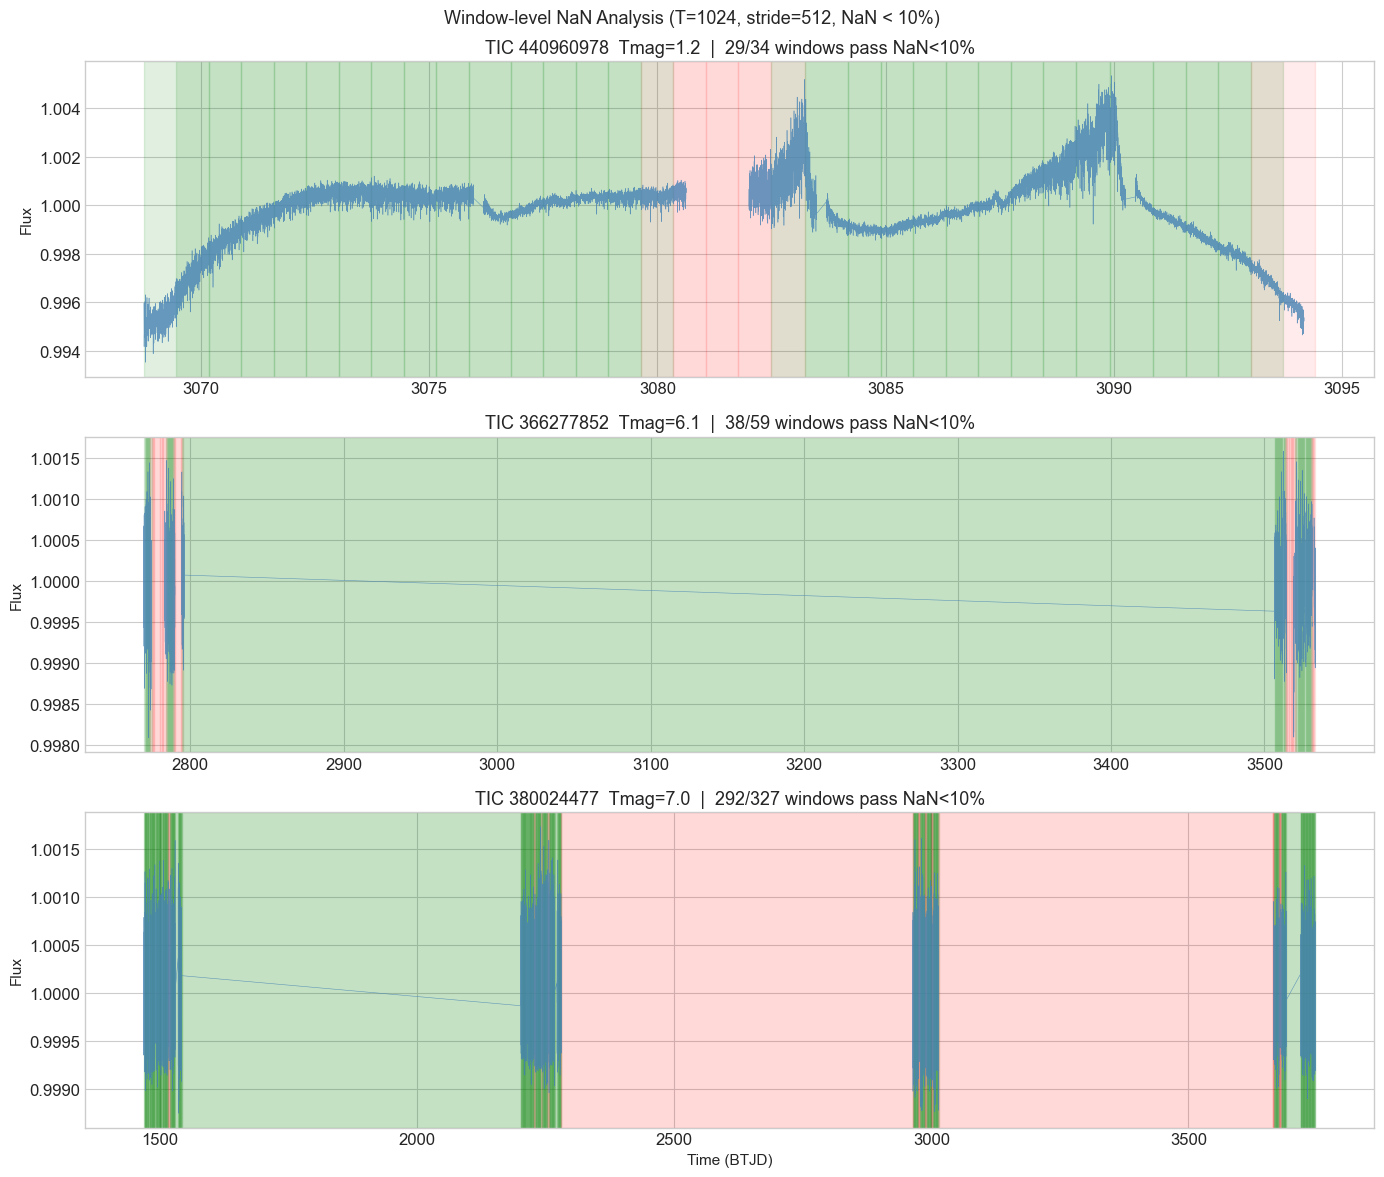

In [9]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

T = 1024
STRIDE = 512
NAN_THRESHOLD = 0.10

_window_summary = []

if len(df_final) == 0:
    print("df_final is empty — skipping window-level analysis.")
else:
    df_rep = df_final.sort_values('Tmag').reset_index(drop=True)
    n = len(df_rep)
    idxs = [0, n // 2, n - 1] if n >= 3 else list(range(n))
    rep_stars = df_rep.iloc[idxs].reset_index(drop=True)

    fig, axes = plt.subplots(len(rep_stars), 1, figsize=(14, 4 * len(rep_stars)), squeeze=False)

    for i, (_, row) in enumerate(rep_stars.iterrows()):
        tic_id = int(row['ID'])
        tmag = row['Tmag']
        ax = axes[i][0]
        try:
            sr = lk.search_lightcurve(f"TIC {tic_id}", mission="TESS", author="SPOC", exptime=120)
            lc_col = sr.download_all().stitch()
            flux = lc_col.flux.value.copy().astype(float)
            time_arr = lc_col.time.value

            # Apply QUALITY flag mask — set cadences with QUALITY != 0 to NaN
            try:
                quality = lc_col.quality.value
                flux[quality != 0] = np.nan
            except AttributeError:
                pass

            # Slide window T=1024, stride=512
            n_pts = len(flux)
            window_starts = list(range(0, n_pts - T + 1, STRIDE))
            n_total = len(window_starts)
            n_pass = 0
            pass_flags = []
            for s in window_starts:
                nan_frac = np.sum(np.isnan(flux[s:s + T])) / T
                ok = nan_frac < NAN_THRESHOLD
                pass_flags.append(ok)
                if ok:
                    n_pass += 1

            pct = 100 * n_pass / n_total if n_total > 0 else 0.0
            print(f"TIC {tic_id} (Tmag={tmag:.1f}): {n_total} total windows, "
                  f"{n_pass} pass NaN<10% cut ({pct:.0f}% survival)")
            _window_summary.append({'tic_id': tic_id, 'n_total': n_total, 'n_pass': n_pass})

            # Plot light curve with green (pass) / red (fail) window shading
            ax.plot(time_arr, flux, lw=0.4, color='steelblue', alpha=0.8)
            for s, ok in zip(window_starts, pass_flags):
                t_start = time_arr[s]
                t_end = time_arr[min(s + T - 1, n_pts - 1)]
                ax.axvspan(t_start, t_end, color='green' if ok else 'red',
                           alpha=0.12 if ok else 0.08)
            ax.set_title(f"TIC {tic_id}  Tmag={tmag:.1f}  |  {n_pass}/{n_total} windows pass NaN<10%",
                         fontsize=13)
            ax.set_ylabel("Flux", fontsize=11)
        except Exception as e:
            ax.text(0.5, 0.5, f"TIC {tic_id}: download failed\n{e}",
                    ha='center', va='center', transform=ax.transAxes, fontsize=10)
            _window_summary.append({'tic_id': tic_id, 'n_total': 0, 'n_pass': 0})
            print(f"TIC {tic_id} (Tmag={tmag:.1f}): download failed — {e}")

    axes[-1][0].set_xlabel("Time (BTJD)", fontsize=11)
    fig.suptitle("Window-level NaN Analysis (T=1024, stride=512, NaN < 10%)", fontsize=13)
    plt.tight_layout()
    plt.show()

In [10]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

T              = 1024
STRIDE         = 512
CADENCE_DAYS   = 2 / 1440   # TESS 2-min cadence in days
NAN_THRESHOLD  = 0.10

def _regrid(time_arr, flux_arr):
    """Map observations onto a uniform 2-min grid; gaps become NaN."""
    t0      = time_arr[0]
    indices = np.round((time_arr - t0) / CADENCE_DAYS).astype(int)
    n_grid  = indices[-1] + 1
    t_grid  = t0 + np.arange(n_grid) * CADENCE_DAYS
    f_grid  = np.full(n_grid, np.nan)
    f_grid[indices] = flux_arr
    return t_grid, f_grid

def plot_window(star_idx, sector_idx=0, window_idx=0):
    row    = df_final.iloc[star_idx]
    tic_id = int(row['ID'])
    print(f"Star #{star_idx}: TIC {tic_id}  Tmag={row['Tmag']:.2f}  "
          f"Teff={row['Teff']:.0f} K  logg={row['logg']:.2f}")

    sr = lk.search_lightcurve(f"TIC {tic_id}", mission="TESS", author="SPOC", exptime=120)
    if len(sr) == 0:
        print("No SPOC 2-min data found.")
        return

    sectors    = list(sr.table['sequence_number'])
    sector_idx = min(sector_idx, len(sr) - 1)
    print(f"Available sectors ({len(sectors)}): {sectors}")
    print(f"Using sector index {sector_idx} → Sector {sectors[sector_idx]}")

    lc       = sr[sector_idx].download()
    raw_flux = lc.flux.value.astype(float)
    raw_time = lc.time.value

    # ── Reindex onto uniform 2-min grid so gaps appear as NaN ────────────────
    time_grid, flux_grid = _regrid(raw_time, raw_flux)
    n_grid   = len(flux_grid)
    n_nan    = int(np.isnan(flux_grid).sum())
    nan_pct  = 100 * n_nan / n_grid

    print(f"\n── Sector {sectors[sector_idx]} NaN summary ──────────────────")
    print(f"  Downloaded cadences : {len(raw_flux)}")
    print(f"  Uniform grid points : {n_grid}")
    print(f"  NaN (gaps)          : {n_nan} / {n_grid}  ({nan_pct:.2f}%)")

    # ── Per-window NaN breakdown ──────────────────────────────────────────────
    starts     = list(range(0, n_grid - T + 1, STRIDE))
    nan_counts = [int(np.isnan(flux_grid[s : s + T]).sum()) for s in starts]
    n_pass     = sum(1 for c in nan_counts if c / T < NAN_THRESHOLD)
    print(f"\n── Window breakdown (T={T}, stride={STRIDE}) ─────────────────")
    print(f"  Total windows : {len(starts)}")
    print(f"  Pass NaN<10%  : {n_pass} / {len(starts)}")
    print(f"  Per-window NaN counts:")
    for wi, (s, nc) in enumerate(zip(starts, nan_counts)):
        marker = " ✓" if nc / T < NAN_THRESHOLD else " ✗"
        sel    = " ← selected" if wi == min(window_idx, len(starts)-1) else ""
        print(f"    [{wi:>3}] cadences [{s:>5}, {s+T:>5})  NaN={nc:>4}/{T}  "
              f"({100*nc/T:>5.1f}%){marker}{sel}")

    # ── Plot selected window ──────────────────────────────────────────────────
    window_idx = min(window_idx, len(starts) - 1)
    s          = starts[window_idx]
    win_flux   = flux_grid[s : s + T]
    win_time   = time_grid[s : s + T]
    nan_count  = nan_counts[window_idx]

    fig, axes = plt.subplots(2, 1, figsize=(14, 7))

    axes[0].plot(time_grid, flux_grid, lw=0.5, color='steelblue', alpha=0.8)
    axes[0].axvspan(win_time[0], win_time[-1], color='orange', alpha=0.30,
                    label=f'Window {window_idx}')
    axes[0].set_title(
        f"TIC {tic_id} — Sector {sectors[sector_idx]} (uniform grid)  |  "
        f"NaN: {n_nan}/{n_grid} ({nan_pct:.1f}%)", fontsize=12)
    axes[0].set_ylabel("PDCSAP Flux")
    axes[0].legend(fontsize=10)

    axes[1].plot(win_time, win_flux, lw=0.8, color='darkorange', marker='.', ms=2)
    axes[1].set_title(
        f"Window {window_idx}  |  grid pts [{s}, {s+T})  |  "
        f"NaN: {nan_count}/{T} ({100*nan_count/T:.1f}%)", fontsize=12)
    axes[1].set_xlabel("Time (BTJD)")
    axes[1].set_ylabel("PDCSAP Flux")

    plt.suptitle(
        f"TIC {tic_id}  Tmag={row['Tmag']:.2f}  "
        f"Teff={row['Teff']:.0f} K  logg={row['logg']:.2f}",
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

Star #3: TIC 373061126  Tmag=6.35  Teff=7134 K  logg=4.04
Available sectors (5): [np.int64(18), np.int64(19), np.int64(24), np.int64(25), np.int64(52)]
Using sector index 1 → Sector 19

── Sector 19 NaN summary ──────────────────
  Downloaded cadences : 17051
  Uniform grid points : 18047
  NaN (gaps)          : 1122 / 18047  (6.22%)

── Window breakdown (T=1024, stride=512) ─────────────────
  Total windows : 34
  Pass NaN<10%  : 30 / 34
  Per-window NaN counts:
    [  0] cadences [    0,  1024)  NaN= 123/1024  ( 12.0%) ✗ ← selected
    [  1] cadences [  512,  1536)  NaN=  60/1024  (  5.9%) ✓
    [  2] cadences [ 1024,  2048)  NaN=  21/1024  (  2.1%) ✓
    [  3] cadences [ 1536,  2560)  NaN=   4/1024  (  0.4%) ✓
    [  4] cadences [ 2048,  3072)  NaN=   1/1024  (  0.1%) ✓
    [  5] cadences [ 2560,  3584)  NaN=   5/1024  (  0.5%) ✓
    [  6] cadences [ 3072,  4096)  NaN=  24/1024  (  2.3%) ✓
    [  7] cadences [ 3584,  4608)  NaN=  19/1024  (  1.9%) ✓
    [  8] cadences [ 4096,  5120)

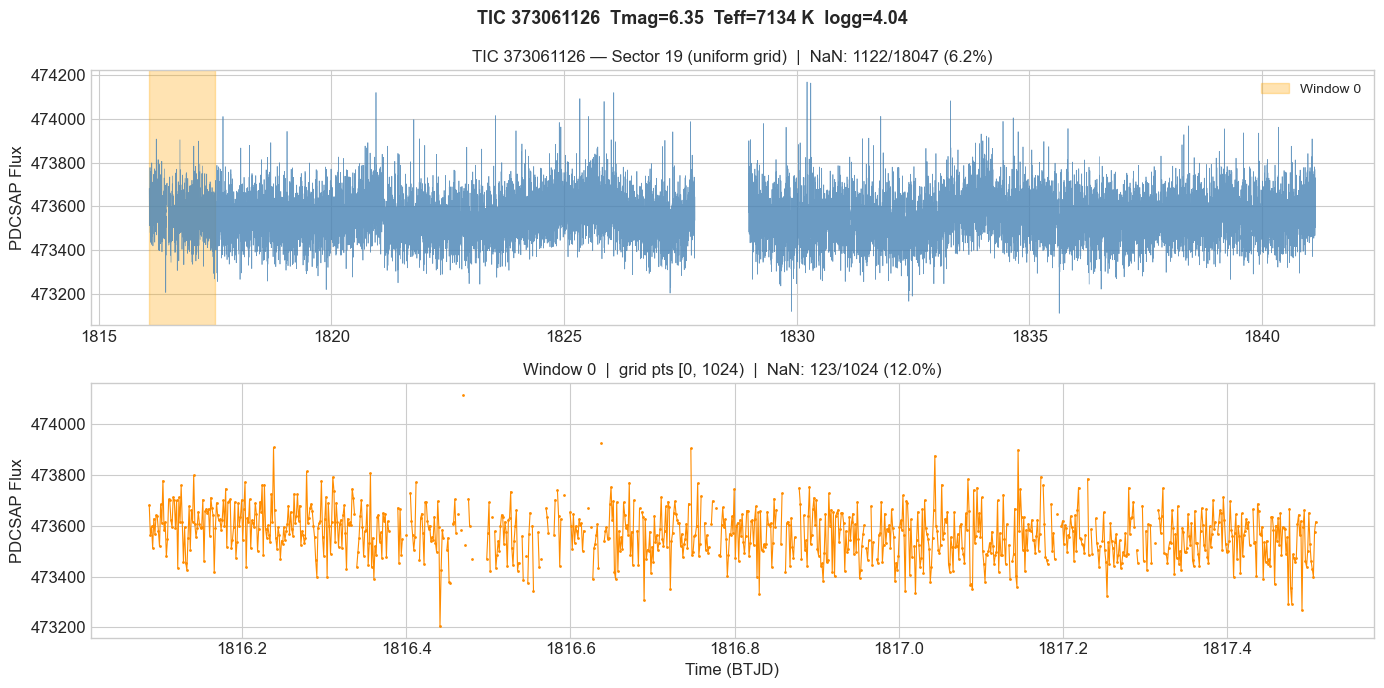

In [11]:
plot_window(star_idx=3, sector_idx=1, window_idx=0)

In [10]:
# ---- Final Quality Cut Summary ----
print("========== Quality Cut Summary ==========")
print(f"Initial TIC sample:              {len(df_raw):>6} stars")
print(f"After Tmag < 7:                  {_n_after_tmag:>6} stars")
print(f"After parallax > 10 mas:         {_n_after_plx:>6} stars")
if _n_after_split is not None:
    print(f"After excluding SPLIT:           {_n_after_split:>6} stars")
else:
    print( "After excluding SPLIT:           skipped - column not found")
print(f"After n_sectors >= 1:            {len(df_final):>6} stars  <- df_final")
print()
print("Window-level preview (3 stars):")
for entry in _window_summary:
    print(f"  TIC {entry['tic_id']}: {entry['n_pass']}/{entry['n_total']} windows pass NaN<10%")
print()

========== Quality Cut Summary ==========
Initial TIC sample:               41233 stars
After Tmag < 7:                    7121 stars
After parallax > 10 mas:           7121 stars
After excluding SPLIT:           skipped - column not found
After n_sectors >= 1:              6654 stars  <- df_final

Window-level preview (3 stars):
  TIC 440960978: 0/0 windows pass NaN<10%
  TIC 366277852: 38/59 windows pass NaN<10%
  TIC 380024477: 292/327 windows pass NaN<10%



---
## Export df_final

Save the filtered TIC list to `processed/df_final.csv` so the downstream pipeline scripts (`build_sequences.py`, `build_labels.py`) can pick it up.

In [11]:
# Pipeline A step 6 — export df_final to processed/df_final.csv
from pathlib import Path

# Walk up from CWD until we find CLAUDE.md (project-root marker).
# This makes the cell robust to whether Jupyter starts in src/notebooks/ or the project root.
project_root = Path.cwd()
while project_root.parent != project_root and not (project_root / 'CLAUDE.md').exists():
    project_root = project_root.parent
if not (project_root / 'CLAUDE.md').exists():
    raise FileNotFoundError('Could not find project root (CLAUDE.md not found in CWD or any parent)')

assert 'ID' in df_final.columns, "df_final must contain an 'ID' column (TIC ID)"

out_path = project_root / 'processed' / 'df_final.csv'
out_path.parent.mkdir(parents=True, exist_ok=True)
df_final.to_csv(out_path, index=False)

print(f'Exported {len(df_final)} TIC IDs to {out_path}')
print(f'Columns: {list(df_final.columns)}')

Exported 6654 TIC IDs to c:\git_repo\Stellar-World-Model\processed\df_final.csv
Columns: ['ID', 'Tmag', 'Teff', 'logg', 'MH', 'plx', 'rad', 'mass', 'GAIAmag', 'gaiaBp', 'gaiaRp', 'TIC_ID', 'n_sectors']
